__libraries__

In [156]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
import os
import plotly.graph_objects as go

----------------------------------------------------------

__inputs__

In [159]:
#enrichment thresholds
strength_threshold= 1.25
fdr_threshold= 0.05

#mysql server connection parameters
mysql_username= 'root'
mysql_password= 'poef.qve5353'
mysql_hostname= '127.0.0.1'
mysql_port= '3306'

#paths to folders
path_to_folder_decreased_formation= r"C:\Users\Jakub\Desktop\clusters\1_decreased_formation\decreased_formation_enrichments"
path_to_folder_disrupted_relocation_and_fusion= r"C:\Users\Jakub\Desktop\clusters\2_disrupted_relocation_and_fusion\disrupted_relocation_and_fusion_enrichments"
path_to_folder_slower_clearance= r"C:\Users\Jakub\Desktop\clusters\3_slower_clearance\slower_clearance_enrichments"

-----------------------------------------------------------------------------------------------------------

__data processing functions__

In [162]:
#data load from 'hc_microscopy_data_v2' database
def GO_based_enrichments_load_from_sql_db(username= mysql_username, password=mysql_password, hostname= mysql_hostname, port= mysql_port, str_thr=strength_threshold, fdr_thr= fdr_threshold, cluster_summary=False):
    
    #connection
    connection_string = f"mysql+pymysql://{username}:{password}@{hostname}:{port}/hc_microscopy_data_v2"
    engine = create_engine(connection_string) 
    
    #query (stored procedure call) + parameters
    query = "call p_clusters_enrichments (%s, %s)"
    param1= str_thr
    param2= fdr_thr
    
    #data load
    data= pd.read_sql(query, engine, params= (param1, param2))
    
    #fix potential '\r' suffixes
    data= data.assign(effect_stage_label= data.effect_stage_label.apply(lambda x: x.rstrip('\r')),
                      cluster_label= data.cluster_label.apply(lambda x: x.rstrip('\r')),
                      enrichment_description= data.enrichment_description.apply(lambda x: x.rstrip('\r')),
                      go_enrichment_id= data.go_enrichment_id.apply(lambda x: x.rstrip('\r')))
    
    #rename columns
    data.columns= ['effect-stage label', 'cluster label', 'GO enrichment category', 'GO enrichment ID', 'enrichment description', 'strength', 'FDR', 'nodes per cluster', 'enrichments per cluster']
    
    if cluster_summary== True: #retains 2 extra columns: nodes_per_cluster and enrichments_per_cluster
        return data
    else: #columns removed
        return data.iloc[:, :-2]
    
    
def set_merger(set_series):
    
    #creates list of sets
    list_of_sets= list(set_series)
    
    #set merger: set of unique genes in a cluster
    merged= set().union(*list_of_sets)
    
    #number of genes in a cluster
    return len(merged)
        
       
#data load from folders (containing files with enrichments for each cluster)
def GO_based_enrichments_load_from_folder(str_thr=strength_threshold, fdr_thr= fdr_threshold, path_to_folder1= path_to_folder_decreased_formation, path_to_folder2= path_to_folder_disrupted_relocation_and_fusion, path_to_folder3= path_to_folder_slower_clearance, category_label1= 'decreased_formation', category_label2= 'disrupted_relocation_and_fusion', category_label3= 'slower_clearance'):
    
    #load data for each category (effect-stage)
    data1= pd.DataFrame() #empty dataframe
    #for each enrichment .tsv file (one file correspondng to each cluster)
    for enrichment_file in os.listdir(path_to_folder1):
        #name of the assigned cluster (e.g. ribosome assembly)
        enr_name= enrichment_file[:-20] #file name with '.tsv' removed
        #path to specific enrichment .tsv file
        enr_path= os.path.join(path_to_folder1, enrichment_file) # path to a single plate
        #load each file, select columns
        enr_data= pd.read_csv(enr_path,
                              delimiter= '\t',
                              usecols= ['#category', 'term ID', 'term description', 'matching proteins in your network (IDs)', 'strength', 'false discovery rate']) #plate data load       
        #assign cluster_label (cluster name)
        enr_data= enr_data.assign(cluster_label= enr_name)        
        #concat the specific enrichment file to a final dataset
        data1= pd.concat([data1, enr_data], ignore_index= True)    
    #assign stage_category_label to a final file (e.g., decreased_formation)
    data1= data1.assign(stage_category_label= category_label1)
    
    data2= pd.DataFrame() #empty dataframe
    #for each enrichment .tsv file (one file correspondng to each cluster)
    for enrichment_file in os.listdir(path_to_folder2):
        #name of the assigned cluster (e.g. ribosome assembly)
        enr_name= enrichment_file[:-20] #file name with '.tsv' removed
        #path to specific enrichment .tsv file
        enr_path= os.path.join(path_to_folder2, enrichment_file) # path to a single plate
        #load each file, select columns
        enr_data= pd.read_csv(enr_path,
                              delimiter= '\t',
                              usecols= ['#category', 'term ID', 'term description', 'matching proteins in your network (IDs)', 'strength', 'false discovery rate']) #plate data load       
        #assign cluster_label (cluster name)
        enr_data= enr_data.assign(cluster_label= enr_name)        
        #concat the specific enrichment file to a final dataset
        data2= pd.concat([data2, enr_data], ignore_index= True)    
    #assign stage_category_label to a final file (e.g., decreased_formation)
    data2= data2.assign(stage_category_label= category_label2)    
    
    data3= pd.DataFrame() #empty dataframe
    #for each enrichment .tsv file (one file correspondng to each cluster)
    for enrichment_file in os.listdir(path_to_folder3):
        #name of the assigned cluster (e.g. ribosome assembly)
        enr_name= enrichment_file[:-20] #file name with '.tsv' removed
        #path to specific enrichment .tsv file
        enr_path= os.path.join(path_to_folder3, enrichment_file) # path to a single plate
        #load each file, select columns
        enr_data= pd.read_csv(enr_path,
                              delimiter= '\t',
                              usecols= ['#category', 'term ID', 'term description', 'matching proteins in your network (IDs)', 'strength', 'false discovery rate']) #plate data load       
        #assign cluster_label (cluster name)
        enr_data= enr_data.assign(cluster_label= enr_name)        
        #concat the specific enrichment file to a final dataset
        data3= pd.concat([data3, enr_data], ignore_index= True)    
    #assign stage_category_label to a final file (e.g., decreased_formation)
    data3= data3.assign(stage_category_label= category_label3)    
    
    #concat the three datasets
    data= pd.concat([data1, data2, data3], axis= 0)
    
    #filter down to GO Biological Process- and GO Cellular Component- based enrichments
    data= data.loc[data['#category'].isin(['GO Component', 'GO Process'])]
    
    #reorder and rename columns
    data.columns= ['GO enrichment category', 'GO enrichment ID', 'enrichment description', 'strength', 'FDR', 'nodes per cluster', 'cluster label', 'effect-stage label']
    data= data.reindex(columns= ['effect-stage label', 'cluster label', 'GO enrichment category', 'GO enrichment ID', 'enrichment description', 'strength', 'FDR', 'nodes per cluster'])
    
    #sort data
    data=data.sort_values(['cluster label', 'GO enrichment category'])
    
    #calculating the number of enrichments per each cluster
    data['enrichments per cluster']= data.groupby('cluster label')['enrichment description'].transform(lambda x: len(x))
    
    #transforming gene lists into sets
    data['nodes per cluster']= data['nodes per cluster'].apply(lambda x: set(x.split(',')))
    
    #calculates the size of a cluster (no. of nodes) connected to enrichments, not always equal to the actual size of a cluster!, used for semi-accurate sorting based on cluster size
    data['nodes per cluster']= data.groupby('cluster label')['nodes per cluster'].transform(lambda x: set_merger(x))
    
    #change the scientific format to decimal for FDR
    data= data.assign(FDR= data.FDR.round(4))
    
    #remove '_' from 'StageCategoryLabel' and 'ClusterLabel' + further format 'ClusterLabel'
    data['effect-stage label']= data['effect-stage label'].apply(lambda x: x.replace('_', ' '))
    data['enrichment description']= data['enrichment description'].apply(lambda x: x.replace(',', ';'))
    data['cluster label']= data['cluster label'].apply(lambda x: x.replace('_', ' ').replace('mrna', 'mRNA').replace('dna', 'DNA').replace('sec62 63', 'Sec62/Sec63').replace('rna', 'RNA'))
    
    #format 'GOEnrichmentCategory'
    data['GO enrichment category']= np.where(data['GO enrichment category']=='GO Process', 'GO Biological Process', 'GO Cellular Compartment')

    #filter based on 'strength' and 'FDR'
    data= data.loc[(data.strength >= str_thr) &
                   (data.FDR < fdr_thr)].reset_index(drop= True)
    
    #sort data based on no. of encrichments
    data= data.sort_values(['effect-stage label', 'nodes per cluster', 'cluster label', 'GO enrichment category', 'strength'], ascending= [True, False, True, True, False], ignore_index= True)
    
    #filter out sorting columns
    data= data.iloc[:, :-2]
    
    #specify number of decimals to display (! resulting values are in text format)
    data= data.assign(strength= data.strength.apply(lambda x: f"{x:.2f}"),
                      FDR= data.FDR.apply(lambda x: f"{x:.4f}"))
    
    return data

# 'db' to load from mysql database, 'raw file' to load from a file
def data_load(source):
    if source=='db':
        data= GO_based_enrichments_load_from_sql_db(str_thr=0, fdr_thr= 1) #no filtering (stength/fdr-based conditional formatting applied in visuals)
        return data
    elif source=='folder':
        data= GO_based_enrichments_load_from_folder(str_thr=0, fdr_thr= 1) #no filtering (stength/fdr-based conditional formatting applied in visuals)
        return data
    else:
        raise ValueError(f"Invalid source input: '{source}'. Expected: 'db' (for database) or 'folder' for folder.")

__visualisation functions__

In [164]:
def enrichment_table(data):
    
    #header
    head= list(data.columns)
    
    #columns
    col1= list(data.loc[:, 'effect-stage label'])
    col2= list(data.loc[:, 'cluster label'])
    col3= list(data.loc[:, 'GO enrichment category'])
    col4= list(data.loc[:, 'GO enrichment ID'])
    col5= list(data.loc[:, 'enrichment description'])
    col6= list(data.loc[:, 'strength'])
    col7= list(data.loc[:, 'FDR'])
    
    #conditional formatting (effect-stage label, strength and FDR)
    col1_colors= ['#DFE9F5' if stage== 'decreased formation' else '#FEE7CC' if stage in ['disrupted relocation and fusion', 'disrupted relocation & fusion'] else '#D6FED2' for stage in col1]
    col6_colors= ['#F88379' if float(strength) < strength_threshold else '#ADEBB3' for strength in col6]
    col7_colors= ['#F88379' if float(fdr) > fdr_threshold else '#ADEBB3' for fdr in col7]
    
    
    #table visual
    fig = go.Figure(data=[go.Table(
                               columnwidth= [0.9, 0.75, 0.75, 0.5, 2, 0.3, 0.3],
                               header=dict(values= head, 
                                           fill_color="lightgray", 
                                           align="center", 
                                           font=dict(family="Calibri Bold", 
                                                     size=15)),
                               cells=dict(values=[col1, col2, col3, col4, col5, col6, col7], 
                                          fill_color=[col1_colors, ['white'] * len(col1), ['white'] * len(col1), ['white'] * len(col1), ['white'] * len(col1), col6_colors, col7_colors], 
                                          align="center", 
                                          font=dict(size=12)))
                           ]
                    )

    #resize
    fig.update_layout(width=1900, height= 22 * len(col1))

    #show
    fig.show()

----------------------------------------------------------------------------------------------------

__data load__

In [167]:
enrichments_data= data_load('folder')
enrichments_data.head()

,effect-stage label,cluster label,GO enrichment category,GO enrichment ID,enrichment description,strength,FDR
0,decreased formation,ribosome assembly,GO Biological Process,GO:0042256,Mature ribosome assembly,1.49,0.0305
1,decreased formation,ribosome assembly,GO Biological Process,GO:1902626,Assembly of large subunit precursor of preribo...,1.37,0.0483
2,decreased formation,ribosome assembly,GO Biological Process,GO:0042255,Ribosome assembly,1.24,0.0026
3,decreased formation,ribosome assembly,GO Biological Process,GO:0000463,Maturation of LSU-rRNA from tricistronic rRNA ...,1.15,0.0010
4,decreased formation,ribosome assembly,GO Biological Process,GO:0042273,Ribosomal large subunit biogenesis,1.05,0.0001


--------------------------------------------------------------------------------

__visualisation__

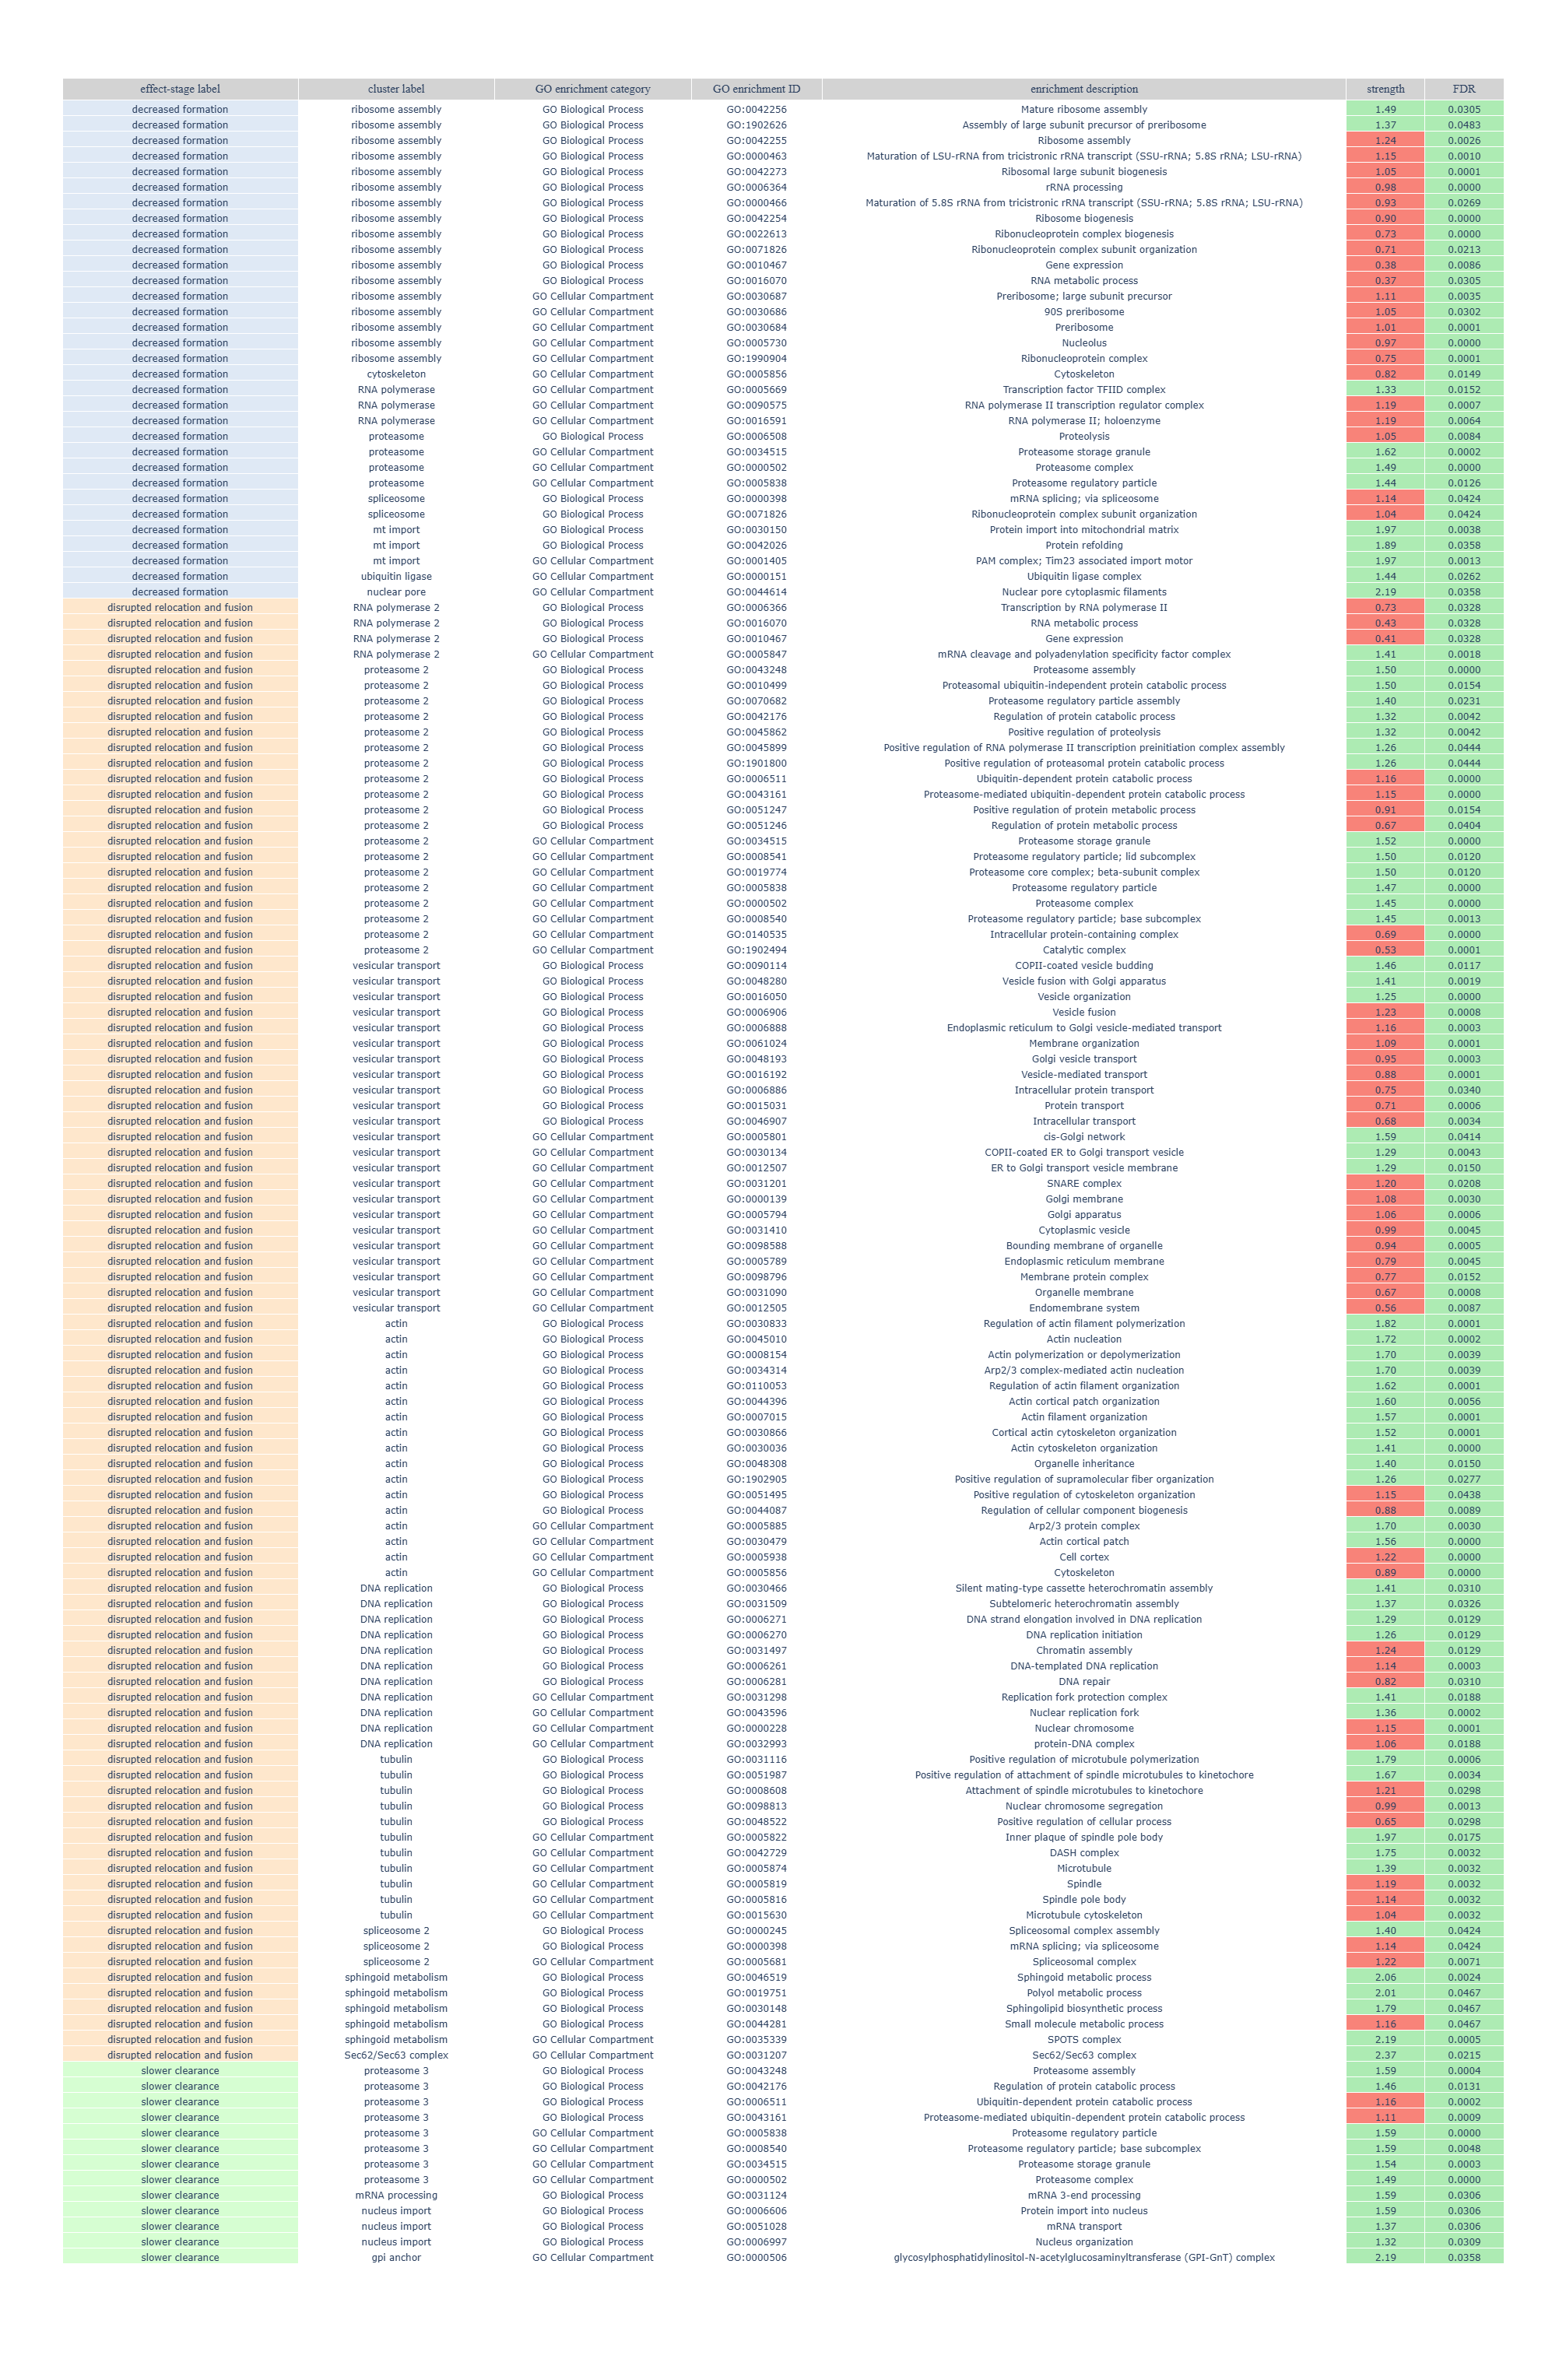

In [170]:
enrichment_table(enrichments_data)